# Teaching a model to prefer extra-concise geography answers with DPO

The question we will try to answer is:

> Can a small DPO run make an instruction-tuned model answer **geography questions more concisely** without losing correctness?

What we will do:
1. Build a **geography-first synthetic preference dataset** from structured country facts.
2. Use **templates** such as `What is the capital of {country}?` to generate many prompt variants automatically.
3. Optionally use a **small LLM** to paraphrase templates so the training prompts are less repetitive.
4. Train a policy model against a frozen reference model with DPO.
5. Compare behavior **before vs. after DPO** on held-out geography questions.

This notebook was inspired by the DPO exercise in the supplemental code to the book **Build a Large Language Model From Scratch** by Sebastian Raschka.

Original code repository: https://github.com/rasbt/LLMs-from-scratch

## Setup
A GPU is strongly recommended.

In [6]:
!pip -q install transformers accelerate pandas matplotlib sentencepiece

We begin by:

* Defining a structured geography knowledge base.
* Turning those facts into many instruction-style prompts automatically.
* Creating preference pairs where the model should prefer a **minimal answer** (for example `Paris`) over a wordier one (for example `The answer is Paris.`).


Here are the steps:

* Start from country facts such as `country`, `capital`, and `continent`.
* Generate many question variants from templates.
* Optionally ask a **small LLM** to paraphrase some templates while preserving placeholders like `{country}` and `{capital}`.
* Train DPO on concise-vs-verbose answer pairs.

This keeps the facts grounded while still giving the model much more stylistic variety.

In [ ]:
import random
import re

COUNTRY_FACTS = [
    {"country": "Algeria", "capital": "Algiers", "continent": "Africa"},
    {"country": "Argentina", "capital": "Buenos Aires", "continent": "South America"},
    {"country": "Australia", "capital": "Canberra", "continent": "Oceania"},
    {"country": "Austria", "capital": "Vienna", "continent": "Europe"},
    {"country": "Belgium", "capital": "Brussels", "continent": "Europe"},
    {"country": "Brazil", "capital": "Brasilia", "continent": "South America"},
    {"country": "Cameroon", "capital": "Yaounde", "continent": "Africa"},
    {"country": "Canada", "capital": "Ottawa", "continent": "North America"},
    {"country": "Chile", "capital": "Santiago", "continent": "South America"},
    {"country": "China", "capital": "Beijing", "continent": "Asia"},
    {"country": "Colombia", "capital": "Bogota", "continent": "South America"},
    {"country": "Costa Rica", "capital": "San Jose", "continent": "North America"},
    {"country": "Croatia", "capital": "Zagreb", "continent": "Europe"},
    {"country": "Czech Republic", "capital": "Prague", "continent": "Europe"},
    {"country": "Denmark", "capital": "Copenhagen", "continent": "Europe"},
    {"country": "Ecuador", "capital": "Quito", "continent": "South America"},
    {"country": "Egypt", "capital": "Cairo", "continent": "Africa"},
    {"country": "Estonia", "capital": "Tallinn", "continent": "Europe"},
    {"country": "Ethiopia", "capital": "Addis Ababa", "continent": "Africa"},
    {"country": "Finland", "capital": "Helsinki", "continent": "Europe"},
    {"country": "France", "capital": "Paris", "continent": "Europe"},
    {"country": "Germany", "capital": "Berlin", "continent": "Europe"},
    {"country": "Ghana", "capital": "Accra", "continent": "Africa"},
    {"country": "Greece", "capital": "Athens", "continent": "Europe"},
    {"country": "Hungary", "capital": "Budapest", "continent": "Europe"},
    {"country": "Iceland", "capital": "Reykjavik", "continent": "Europe"},
    {"country": "India", "capital": "New Delhi", "continent": "Asia"},
    {"country": "Indonesia", "capital": "Jakarta", "continent": "Asia"},
    {"country": "Ireland", "capital": "Dublin", "continent": "Europe"},
    {"country": "Italy", "capital": "Rome", "continent": "Europe"},
    {"country": "Japan", "capital": "Tokyo", "continent": "Asia"},
    {"country": "Jordan", "capital": "Amman", "continent": "Asia"},
    {"country": "Kenya", "capital": "Nairobi", "continent": "Africa"},
    {"country": "Latvia", "capital": "Riga", "continent": "Europe"},
    {"country": "Lithuania", "capital": "Vilnius", "continent": "Europe"},
    {"country": "Luxembourg", "capital": "Luxembourg", "continent": "Europe"},
    {"country": "Malaysia", "capital": "Kuala Lumpur", "continent": "Asia"},
    {"country": "Malta", "capital": "Valletta", "continent": "Europe"},
    {"country": "Mexico", "capital": "Mexico City", "continent": "North America"},
    {"country": "Morocco", "capital": "Rabat", "continent": "Africa"},
    {"country": "Nepal", "capital": "Kathmandu", "continent": "Asia"},
    {"country": "Netherlands", "capital": "Amsterdam", "continent": "Europe"},
    {"country": "New Zealand", "capital": "Wellington", "continent": "Oceania"},
    {"country": "Nigeria", "capital": "Abuja", "continent": "Africa"},
    {"country": "Norway", "capital": "Oslo", "continent": "Europe"},
    {"country": "Pakistan", "capital": "Islamabad", "continent": "Asia"},
    {"country": "Peru", "capital": "Lima", "continent": "South America"},
    {"country": "Philippines", "capital": "Manila", "continent": "Asia"},
    {"country": "Poland", "capital": "Warsaw", "continent": "Europe"},
    {"country": "Portugal", "capital": "Lisbon", "continent": "Europe"},
    {"country": "Romania", "capital": "Bucharest", "continent": "Europe"},
    {"country": "Saudi Arabia", "capital": "Riyadh", "continent": "Asia"},
    {"country": "Serbia", "capital": "Belgrade", "continent": "Europe"},
    {"country": "Singapore", "capital": "Singapore", "continent": "Asia"},
    {"country": "Slovakia", "capital": "Bratislava", "continent": "Europe"},
    {"country": "Slovenia", "capital": "Ljubljana", "continent": "Europe"},
    {"country": "South Korea", "capital": "Seoul", "continent": "Asia"},
    {"country": "Spain", "capital": "Madrid", "continent": "Europe"},
    {"country": "Sweden", "capital": "Stockholm", "continent": "Europe"},
    {"country": "Switzerland", "capital": "Bern", "continent": "Europe"},
    {"country": "Thailand", "capital": "Bangkok", "continent": "Asia"},
    {"country": "Tunisia", "capital": "Tunis", "continent": "Africa"},
    {"country": "Uganda", "capital": "Kampala", "continent": "Africa"},
    {"country": "Ukraine", "capital": "Kyiv", "continent": "Europe"},
    {"country": "United Arab Emirates", "capital": "Abu Dhabi", "continent": "Asia"},
    {"country": "United Kingdom", "capital": "London", "continent": "Europe"},
    {"country": "United States", "capital": "Washington, D.C.", "continent": "North America"},
    {"country": "Uruguay", "capital": "Montevideo", "continent": "South America"},
    {"country": "Vietnam", "capital": "Hanoi", "continent": "Asia"},
    {"country": "Zimbabwe", "capital": "Harare", "continent": "Africa"},
]

BASE_TEMPLATE_BANK = {
    "capital_open": [
        "What is the capital of {country}?",
        "Name the capital of {country}.",
        "Capital of {country}?"
    ],
    "capital_fill_blank": [
        "Fill in the blank: The capital of {country} is ___.",
        "Complete this: {country} -> capital: ___."
    ],
    "country_from_capital": [
        "Which country has {capital} as its capital?",
        "{capital} is the capital of which country?"
    ],
    "continent_of_country": [
        "Which continent is {country} in?",
        "{country} is in which continent?"
    ],
    "continent_of_capital": [
        "Which continent is {capital} in?",
        "{capital} is on which continent?"
    ],
    "capital_mcq": [
        "Which of these is the capital of {country}: {option_a}, {option_b}, or {option_c}?",
        "Choose the capital of {country}: {option_a}, {option_b}, or {option_c}."
    ],
    "capital_yes_no": [
        "Answer yes or no: Is {candidate_capital} the capital of {country}?",
        "True or false: {candidate_capital} is the capital of {country}."
    ],
}

def template_placeholders(template):
    return tuple(sorted(set(re.findall(r"{[^}]+}", template))))

def clean_template_line(text):
    text = text.strip().strip('"').strip("'")
    text = re.sub(r"^[\-\*\d\.\)\s]+", "", text)
    text = text.replace("`", "")
    return text.strip()

def _normalize_template_bank_keys(template_bank):
    normalized = {
        family: list(dict.fromkeys(templates))
        for family, templates in template_bank.items()
    }
    if "capital_multiple_choice" not in normalized and "capital_mcq" in normalized:
        normalized["capital_multiple_choice"] = list(normalized["capital_mcq"])
    elif "capital_multiple_choice" in normalized and "capital_mcq" in normalized:
        normalized["capital_multiple_choice"] = list(
            dict.fromkeys(normalized["capital_multiple_choice"] + normalized["capital_mcq"])
        )
    return normalized


def _make_small_template_paraphraser(model_name):
    import torch
    from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

    device = 0 if torch.cuda.is_available() else -1
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    task_candidates = ["text2text-generation", "text-generation"]
    last_error = None

    for task in task_candidates:
        try:
            return pipeline(
                task,
                model=model,
                tokenizer=tokenizer,
                device=device,
            )
        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        f"Could not create a small-template paraphraser for {model_name}. Last error: {last_error}"
    )


def _extract_generated_text(result):
    if isinstance(result, list) and result:
        first = result[0]
        if isinstance(first, dict):
            if "generated_text" in first:
                return first["generated_text"]
            if "summary_text" in first:
                return first["summary_text"]
    return str(result)


def build_template_bank(
    base_template_bank,
    use_small_llm=True,
    model_name="google/flan-t5-small",
    max_llm_variants_per_family=4,
):
    """
    Optionally augment the hand-written templates with paraphrases from a small LLM.

    The notebook remains usable even if the small model cannot be loaded:
    in that case we simply fall back to the seed templates.
    """
    template_bank = _normalize_template_bank_keys(base_template_bank)

    if not use_small_llm:
        print("Using only hand-written templates.")
        return template_bank

    try:
        paraphraser = _make_small_template_paraphraser(model_name)

        total_new = 0
        for family, templates in list(template_bank.items()):
            seed_template = templates[0]
            required = template_placeholders(seed_template)

            prompt = (
                f"Generate {max_llm_variants_per_family} geography quiz question templates.\n"
                f"Keep the placeholders exactly unchanged: {' '.join(required)}.\n"
                "Return one template per line and nothing else.\n"
                f"Seed template: {seed_template}"
            )

            generated = paraphraser(
                prompt,
                max_new_tokens=192,
                do_sample=False,
                num_beams=max(4, max_llm_variants_per_family + 1),
            )
            generated = _extract_generated_text(generated)

            candidates = []
            for raw_line in re.split(r"[\n;]+", generated):
                line = clean_template_line(raw_line)
                if not line:
                    continue
                if not line.endswith("?") and "___" not in line:
                    continue
                if set(template_placeholders(line)) != set(required):
                    continue
                if line not in candidates and line not in template_bank[family]:
                    candidates.append(line)

            candidates = candidates[:max_llm_variants_per_family]
            template_bank[family].extend(candidates)
            total_new += len(candidates)

        print(f"Added {total_new} template variants with {model_name}.")
        return template_bank

    except Exception as exc:
        print("Small-template-LLM augmentation failed; falling back to seed templates only.")
        print(f"Reason: {type(exc).__name__}: {exc}")
        return template_bank

In [8]:
import random
import string
import hashlib


def _clean_text(value):
    return "" if value is None else str(value).strip()


def format_input(entry):
    instruction = _clean_text(entry.get("instruction", ""))
    extra_input = _clean_text(entry.get("input", ""))
    return instruction if not extra_input else f"{instruction}\n\nContext: {extra_input}"


SYSTEM_MESSAGE = (
    "You are a concise geography assistant. "
    "Answer with only the minimal correct answer and then stop."
)


def build_chat_messages(entry_or_prompt, assistant_text=None, system_message=SYSTEM_MESSAGE):
    if isinstance(entry_or_prompt, dict):
        user_content = format_input(entry_or_prompt)
    else:
        user_content = _clean_text(entry_or_prompt)

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_content},
    ]
    if assistant_text is not None:
        messages.append({"role": "assistant", "content": _clean_text(assistant_text)})
    return messages


def _render_plain_chat(messages, add_generation_prompt=True):
    parts = []
    for msg in messages:
        role = msg["role"].capitalize()
        parts.append(f"{role}: {msg['content']}")
    if add_generation_prompt:
        parts.append("Assistant:")
    return "\n\n".join(parts)


def _apply_chat_template_safe(tokenizer, messages, tokenize, add_generation_prompt):
    apply_chat_template = getattr(tokenizer, "apply_chat_template", None)
    has_chat_template = getattr(tokenizer, "chat_template", None)

    if callable(apply_chat_template) and has_chat_template:
        return apply_chat_template(
            messages,
            tokenize=tokenize,
            add_generation_prompt=add_generation_prompt,
        )

    rendered = _render_plain_chat(messages, add_generation_prompt=add_generation_prompt)
    if tokenize:
        return tokenizer.encode(rendered, add_special_tokens=True)
    return rendered


def render_chat_prompt_ids(entry, tokenizer):
    prompt_ids = _apply_chat_template_safe(
        tokenizer,
        build_chat_messages(entry),
        tokenize=True,
        add_generation_prompt=True,
    )
    # Some tokenizer/chat-template combos ignore tokenize=True and return text.
    # Fall back to encoding the rendered prompt text directly.
    if isinstance(prompt_ids, str):
        prompt_text = render_chat_prompt_text(entry, tokenizer)
        prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    prompt_ids = _ensure_list_ids(prompt_ids)
    if prompt_ids and isinstance(prompt_ids[0], str):
        prompt_text = render_chat_prompt_text(entry, tokenizer)
        prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
        prompt_ids = _ensure_list_ids(prompt_ids)
    return [int(x) for x in prompt_ids]


def render_chat_prompt_text(entry_or_prompt, tokenizer):
    return _apply_chat_template_safe(
        tokenizer,
        build_chat_messages(entry_or_prompt),
        tokenize=False,
        add_generation_prompt=True,
    )



def _ensure_list_ids(token_ids):
    if hasattr(token_ids, "tolist"):
        token_ids = token_ids.tolist()
    return list(token_ids)


def _ensure_list_ids(token_ids):
    if hasattr(token_ids, "tolist"):
        token_ids = token_ids.tolist()
    return list(token_ids)


def _get_message_terminator_ids(tokenizer):
    terminators = []
    eos_token_id = getattr(tokenizer, "eos_token_id", None)
    if eos_token_id is not None:
        terminators.append(int(eos_token_id))

    convert = getattr(tokenizer, "convert_tokens_to_ids", None)
    if callable(convert):
        unk_id = getattr(tokenizer, "unk_token_id", None)
        unk_token = getattr(tokenizer, "unk_token", None)
        for token in ["<|im_end|>", "<|eot_id|>", "</s>", "<|endoftext|>"]:
            token_id = convert(token)
            if token_id is None:
                continue
            if unk_id is not None and token_id == unk_id and token != unk_token:
                continue
            if isinstance(token_id, int) and token_id >= 0:
                terminators.append(int(token_id))

    unique = []
    for tid in terminators:
        if tid not in unique:
            unique.append(tid)
    return unique


def _encode_assistant_completion(tokenizer, entry, assistant_text):
    assistant_text = _clean_text(assistant_text)
    prompt_ids = render_chat_prompt_ids(entry, tokenizer)

    # Preferred path: let the tokenizer encode the *full* assistant turn, then
    # recover only the assistant continuation suffix. This preserves model-specific
    # chat boundary markers such as <|im_end|>.
    full_chat_ids = _apply_chat_template_safe(
        tokenizer,
        build_chat_messages(entry, assistant_text=assistant_text),
        tokenize=True,
        add_generation_prompt=False,
    )
    if isinstance(full_chat_ids, str):
        full_chat_text = _apply_chat_template_safe(
            tokenizer,
            build_chat_messages(entry, assistant_text=assistant_text),
            tokenize=False,
            add_generation_prompt=False,
        )
        full_chat_ids = tokenizer.encode(full_chat_text, add_special_tokens=False)

    full_chat_ids = _ensure_list_ids(full_chat_ids)
    prompt_ids = _ensure_list_ids(prompt_ids)

    if len(full_chat_ids) > len(prompt_ids) and full_chat_ids[:len(prompt_ids)] == prompt_ids:
        response_ids = full_chat_ids[len(prompt_ids):]
    else:
        # Fallback: plain answer tokens + best-known terminator.
        response_ids = _ensure_list_ids(tokenizer.encode(assistant_text, add_special_tokens=False))
        terminators = _get_message_terminator_ids(tokenizer)
        if terminators:
            if len(response_ids) == 0 or response_ids[-1] not in terminators:
                response_ids = response_ids + [terminators[0]]

    return [int(x) for x in response_ids]


def render_chat_completion_ids(entry, tokenizer, assistant_text):
    prompt_ids = [int(x) for x in render_chat_prompt_ids(entry, tokenizer)]
    response_ids = _encode_assistant_completion(tokenizer, entry, assistant_text)
    full_ids = prompt_ids + response_ids

    if len(full_ids) <= len(prompt_ids):
        raise ValueError("Assistant completion encoding produced no response tokens.")

    return {
        "prompt_ids": prompt_ids,
        "full_ids": [int(x) for x in full_ids],
        "response_start": len(prompt_ids),
    }


def get_stop_token_ids(tokenizer):

    stop_ids = []

    if getattr(tokenizer, "eos_token_id", None) is not None:
        stop_ids.append(int(tokenizer.eos_token_id))

    convert = getattr(tokenizer, "convert_tokens_to_ids", None)
    if callable(convert):
        unk_id = getattr(tokenizer, "unk_token_id", None)
        unk_token = getattr(tokenizer, "unk_token", None)

        for token in ["<|im_end|>", "</s>", "<|endoftext|>"]:
            token_id = convert(token)
            if token_id is None:
                continue
            if unk_id is not None and token_id == unk_id and token != unk_token:
                continue
            if isinstance(token_id, int) and token_id >= 0:
                stop_ids.append(int(token_id))

    unique_stop_ids = []
    for token_id in stop_ids:
        if token_id not in unique_stop_ids:
            unique_stop_ids.append(token_id)
    return unique_stop_ids


def _stable_index(items_len, *parts):
    if items_len <= 0:
        raise ValueError("items_len must be positive")
    payload = "||".join("" if p is None else str(p) for p in parts)
    digest = hashlib.md5(payload.encode("utf-8")).hexdigest()
    return int(digest, 16) % items_len


def style_pair(answer, task_family, question=None):
    answer = _clean_text(answer)

    continuation_rejections = [
        f"{answer}\n\nThat is the correct answer.",
        f"{answer}\n\nFinal answer: {answer}.",
        f"{answer}\n\n### Instruction\nName another geography fact.",
    ]

    if answer in {"Yes", "No"}:
        base_rejections = [
            f"{answer}, that statement is {'correct' if answer == 'Yes' else 'false'}.",
            f"The answer is {answer}.",
            f"{answer} — that is the correct response.",
        ]
    elif task_family.startswith("capital"):
        base_rejections = [
            f"The answer is {answer}.",
            f"{answer} is the capital.",
            f"The capital is {answer}.",
        ]
    elif task_family.startswith("continent"):
        base_rejections = [
            f"The continent is {answer}.",
            f"The answer is {answer}.",
            f"It is in {answer}.",
        ]
    elif task_family == "country_from_capital":
        base_rejections = [
            f"The country is {answer}.",
            f"The answer is {answer}.",
            f"{answer} is the correct country.",
        ]
    else:
        base_rejections = [
            f"The answer is {answer}.",
            f"It is {answer}.",
        ]

    rejected_options = base_rejections + continuation_rejections
    chosen = answer
    rejected = rejected_options[_stable_index(len(rejected_options), question, answer, task_family)]
    return chosen, rejected


def make_preference_entry(question, answer, fact, task_family):
    chosen, rejected = style_pair(answer, task_family=task_family, question=question)
    return {
        "instruction": question,
        "input": "",
        "output": rejected,
        "chosen": chosen,
        "rejected": rejected,
        "metadata": {
            "correct_answer": _clean_text(answer),
            "domain": "geography",
            "task_family": task_family,
            "country": fact["country"],
            "capital": fact["capital"],
            "continent": fact["continent"],
        },
    }


def sample_templates(templates, k, rng):
    templates = list(templates)
    if not templates:
        return []
    if k >= len(templates):
        return templates[:]
    return rng.sample(templates, k=k)


def _sample_up_to(pool, k, rng):
    pool = list(pool)
    if k <= 0 or not pool:
        return []
    if len(pool) <= k:
        return pool[:]
    return rng.sample(pool, k=k)


def get_same_continent_capital_distractors(target_fact, all_facts, rng, k=2):
    same_continent = [
        item["capital"]
        for item in all_facts
        if item["country"] != target_fact["country"] and item["continent"] == target_fact["continent"]
    ]
    fallback = [
        item["capital"]
        for item in all_facts
        if item["country"] != target_fact["country"]
    ]

    pool = same_continent if len(same_continent) >= k else fallback

    sampled = _sample_up_to(pool, k, rng)

    if len(sampled) < k:
        remaining = [x for x in fallback if x not in sampled]
        sampled.extend(_sample_up_to(remaining, k - len(sampled), rng))

    if len(sampled) < k:
        raise ValueError(
            f"Not enough distractor capitals to sample k={k} for country={target_fact['country']!r}."
        )

    return sampled


def get_false_capital(target_fact, all_facts, rng):
    return get_same_continent_capital_distractors(target_fact, all_facts, rng, k=1)[0]


def get_template_fields(template):
    return {
        field_name
        for _, field_name, _, _ in string.Formatter().parse(template)
        if field_name is not None
    }


_TEMPLATE_ALIASES = {
    "country_name": "country",
    "nation": "country",
    "city": "capital",
    "candidate_city": "candidate_capital",
    "choices": "options",
    "option_text": "options",
}


def render_template(template, **kwargs):
    raw_fields = get_template_fields(template)
    values = dict(kwargs)

    for alias, canonical in _TEMPLATE_ALIASES.items():
        if canonical in values and alias not in values:
            values[alias] = values[canonical]
        if alias in values and canonical not in values:
            values[canonical] = values[alias]

    if "capital" in values and "candidate_capital" not in values:
        values["candidate_capital"] = values["capital"]
    if "candidate_capital" in values and "capital" not in values:
        values["capital"] = values["candidate_capital"]

    missing = [field for field in raw_fields if field not in values]
    if missing:
        raise KeyError(
            f"Missing template fields {missing} for template: {template!r}. "
            f"Available keys: {sorted(values.keys())}"
        )

    return template.format(**values)


def validate_template_bank(template_bank):
    allowed_common = {
        "country",
        "country_name",
        "nation",
        "capital",
        "candidate_capital",
        "city",
        "continent",
        "options",
        "choices",
        "option_text",
        "option_a",
        "option_b",
        "option_c",
    }

    bad_templates = []

    for family, templates in template_bank.items():
        for template in templates:
            fields = get_template_fields(template)
            unexpected = fields - allowed_common
            if unexpected:
                bad_templates.append((family, template, sorted(unexpected)))

    if bad_templates:
        lines = ["Invalid template placeholders found:"]
        for family, template, unexpected in bad_templates:
            lines.append(f"- family={family}, unexpected={unexpected}, template={template!r}")
        raise ValueError("\n".join(lines))


def _get_mcq_templates(template_bank):
    templates = []
    for key in ["capital_multiple_choice", "capital_mcq"]:
        if key in template_bank:
            templates.extend(template_bank[key])
    # preserve order while deduplicating
    return list(dict.fromkeys(templates))


def build_geography_examples_for_fact(
    fact,
    all_facts,
    template_bank,
    rng,
    templates_per_family=2,
):
    rows = []

    for template in sample_templates(template_bank["capital_open"], templates_per_family, rng):
        question = render_template(template, country=fact["country"])
        rows.append(make_preference_entry(question, fact["capital"], fact, "capital_open"))

    for template in sample_templates(template_bank["capital_fill_blank"], templates_per_family, rng):
        question = render_template(template, country=fact["country"])
        rows.append(make_preference_entry(question, fact["capital"], fact, "capital_fill_blank"))

    for template in sample_templates(template_bank["country_from_capital"], templates_per_family, rng):
        question = render_template(template, capital=fact["capital"])
        rows.append(make_preference_entry(question, fact["country"], fact, "country_from_capital"))

    for template in sample_templates(template_bank["continent_of_country"], templates_per_family, rng):
        question = render_template(template, country=fact["country"])
        rows.append(make_preference_entry(question, fact["continent"], fact, "continent_of_country"))

    for template in sample_templates(template_bank["continent_of_capital"], templates_per_family, rng):
        question = render_template(template, capital=fact["capital"])
        rows.append(make_preference_entry(question, fact["continent"], fact, "continent_of_capital"))

    for template in sample_templates(template_bank["capital_yes_no"], templates_per_family, rng):
        false_capital = get_false_capital(fact, all_facts, rng)
        use_true_fact = rng.random() < 0.5
        candidate_capital = fact["capital"] if use_true_fact else false_capital
        answer = "Yes" if use_true_fact else "No"
        question = render_template(
            template,
            country=fact["country"],
            capital=candidate_capital,
            candidate_capital=candidate_capital,
        )
        rows.append(make_preference_entry(question, answer, fact, "capital_yes_no"))

    mcq_templates = _get_mcq_templates(template_bank)
    for template in sample_templates(mcq_templates, templates_per_family, rng):
        distractors = get_same_continent_capital_distractors(fact, all_facts, rng, k=2)
        options = [fact["capital"], *distractors]
        rng.shuffle(options)

        option_labels = ["A", "B", "C"]
        option_map = dict(zip(option_labels, options))
        correct_label = next(label for label, value in option_map.items() if value == fact["capital"])
        option_text = ", ".join(f"{label}) {value}" for label, value in option_map.items())

        question = render_template(
            template,
            country=fact["country"],
            options=option_text,
            option_a=options[0],
            option_b=options[1],
            option_c=options[2],
        )
        rows.append(make_preference_entry(question, correct_label, fact, "capital_multiple_choice"))

    return rows


def build_geography_preference_dataset(
    facts,
    all_facts,
    template_bank,
    seed=123,
    templates_per_family=2,
    validate_templates=True,
):
    if validate_templates:
        validate_template_bank(template_bank)

    rng = random.Random(seed)
    rows = []

    for fact in facts:
        rows.extend(
            build_geography_examples_for_fact(
                fact,
                all_facts=all_facts,
                template_bank=template_bank,
                rng=rng,
                templates_per_family=templates_per_family,
            )
        )

    rng.shuffle(rows)
    return rows

In [9]:
import random

USE_SMALL_TEMPLATE_LLM = True
SMALL_TEMPLATE_MODEL_NAME = "google/flan-t5-small"
TEMPLATES_PER_FAMILY = 2
SPLIT_SEED = 123
DATASET_SEED = 123

template_bank = build_template_bank(
    BASE_TEMPLATE_BANK,
    use_small_llm=USE_SMALL_TEMPLATE_LLM,
    model_name=SMALL_TEMPLATE_MODEL_NAME,
    max_llm_variants_per_family=4,
)

split_rng = random.Random(SPLIT_SEED)
all_country_facts = COUNTRY_FACTS[:]
split_rng.shuffle(all_country_facts)

n_countries = len(all_country_facts)
n_train_countries = int(0.70 * n_countries)
n_val_countries = int(0.15 * n_countries)
n_test_countries = n_countries - n_train_countries - n_val_countries

train_country_facts = all_country_facts[:n_train_countries]
val_country_facts = all_country_facts[n_train_countries:n_train_countries + n_val_countries]
test_country_facts = all_country_facts[n_train_countries + n_val_countries:]

train_data = build_geography_preference_dataset(
    train_country_facts,
    all_facts=COUNTRY_FACTS,
    template_bank=template_bank,
    seed=DATASET_SEED,
    templates_per_family=TEMPLATES_PER_FAMILY,
)

val_data = build_geography_preference_dataset(
    val_country_facts,
    all_facts=COUNTRY_FACTS,
    template_bank=template_bank,
    seed=DATASET_SEED + 1,
    templates_per_family=TEMPLATES_PER_FAMILY,
)

test_data = build_geography_preference_dataset(
    test_country_facts,
    all_facts=COUNTRY_FACTS,
    template_bank=template_bank,
    seed=DATASET_SEED + 2,
    templates_per_family=TEMPLATES_PER_FAMILY,
)

custom_preference_data = train_data + val_data + test_data
all_custom_data = custom_preference_data[:]

print("Active style target: geography-short-answer")
print("Template families:", {k: len(v) for k, v in template_bank.items()})
print("Countries:", len(COUNTRY_FACTS))
print("Train / Val / Test:", len(train_data), len(val_data), len(test_data))
print("Dataset size:", len(custom_preference_data))

0


model.safetensors:  75%|#######4  | 231M/308M [00:00<?, ?B/s]

C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pd\.cache\huggingface\hub\models--google--flan-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Added 0 template variants with google/flan-t5-small.
Active style target: geography-short-answer
Template families: {'capital_open': 3, 'capital_fill_blank': 2, 'country_from_capital': 2, 'continent_of_country': 2, 'continent_of_capital': 2, 'capital_mcq': 2, 'capital_yes_no': 2, 'capital_multiple_choice': 2}
Countries: 70
Train / Val / Test: 686 140 154
Dataset size: 980


In [10]:
for i in range(3):
    entry = custom_preference_data[i]
    print(f"Example {i+1}")
    print("Instruction :", entry["instruction"])
    print("Chosen      :", entry["chosen"])
    print("Rejected    :", entry["rejected"])
    print("Task family :", entry["metadata"]["task_family"])
    print("Country     :", entry["metadata"]["country"])
    print("-" * 80)

Example 1
Instruction : Answer yes or no: Is Ljubljana the capital of Croatia?
Chosen      : No
Rejected    : No

Final answer: No.
Task family : capital_yes_no
Country     : Croatia
--------------------------------------------------------------------------------
Example 2
Instruction : Which of these is the capital of Uganda: Rabat, Kampala, or Harare?
Chosen      : B
Rejected    : B

Final answer: B.
Task family : capital_multiple_choice
Country     : Uganda
--------------------------------------------------------------------------------
Example 3
Instruction : What is the capital of Greece?
Chosen      : Athens
Rejected    : Athens

Final answer: Athens.
Task family : capital_open
Country     : Greece
--------------------------------------------------------------------------------


## Data split

We split **by country** so validation and test prompts come from unseen countries.

In [11]:
from collections import Counter
import pandas as pd

def split_profile(name, entries):
    return pd.DataFrame({
        "split": [name] * len(entries),
        "task_family": [entry["metadata"]["task_family"] for entry in entries],
        "country": [entry["metadata"]["country"] for entry in entries],
    })

profile_df = pd.concat([
    split_profile("train", train_data),
    split_profile("validation", val_data),
    split_profile("test", test_data),
], ignore_index=True)

country_summary = pd.DataFrame([
    {"split": "train", "countries": len(train_country_facts), "examples": len(train_data)},
    {"split": "validation", "countries": len(val_country_facts), "examples": len(val_data)},
    {"split": "test", "countries": len(test_country_facts), "examples": len(test_data)},
])

print(country_summary.to_string(index=False))
print()
print("Training countries (sample):", ", ".join(sorted(item["country"] for item in train_country_facts[:10])))
print("Validation countries:", ", ".join(sorted(item["country"] for item in val_country_facts)))
print("Test countries:", ", ".join(sorted(item["country"] for item in test_country_facts)))
print()

profile_df.groupby(["split", "task_family"]).size().rename("examples").reset_index()

     split  countries  examples
     train         49       686
validation         10       140
      test         11       154

Training countries (sample): Canada, Greece, Iceland, Japan, Malaysia, Malta, New Zealand, South Korea, United Arab Emirates, Uruguay
Validation countries: Austria, Chile, Colombia, Ecuador, Norway, Singapore, Slovakia, Sweden, Switzerland, Thailand
Test countries: Belgium, Cameroon, Costa Rica, Czech Republic, Germany, Hungary, Lithuania, Luxembourg, Serbia, United Kingdom, Vietnam



,split,task_family,examples
0,test,capital_fill_blank,22
1,test,capital_multiple_choice,22
2,test,capital_open,22
3,test,capital_yes_no,22
4,test,continent_of_capital,22
5,test,continent_of_country,22
6,test,country_from_capital,22
7,train,capital_fill_blank,98
8,train,capital_multiple_choice,98
9,train,capital_open,98


Tokenization and batching

We mask the prompt tokens so that DPO scores only the answer portion.

### Chat-formatted DPO pairs and explicit stopping

The DPO examples below now use the **same Qwen chat template for both training and inference**.
Each chosen/rejected completion is rendered as an assistant turn, so the model scores the answer **plus the assistant end-of-turn token** instead of plain text after `### Response:`.

Two additional anti-rambling changes are included:

- some rejected responses deliberately contain the **correct answer followed by extra continuation**
- greedy evaluation uses a smaller `max_new_tokens` budget and the tokenizer's stop tokens

In [12]:

import torch
from torch.utils.data import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _normalize_id_sequence(seq):
    if hasattr(seq, "tolist"):
        seq = seq.tolist()
    if isinstance(seq, torch.Tensor):
        seq = seq.detach().cpu().tolist()
    if isinstance(seq, str):
        return None
    try:
        seq = list(seq)
    except TypeError:
        return None
    normalized = []
    for tok in seq:
        try:
            normalized.append(int(tok))
        except (TypeError, ValueError):
            return None
    return normalized


class PreferenceDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        self.num_skipped_empty = 0

        for entry in data:
            rejected_response = entry["rejected"].strip()
            chosen_response = entry["chosen"].strip()

            if not rejected_response or not chosen_response:
                self.num_skipped_empty += 1
                continue

            chosen_render = render_chat_completion_ids(entry, tokenizer, chosen_response)
            rejected_render = render_chat_completion_ids(entry, tokenizer, rejected_response)

            prompt_tokens = _normalize_id_sequence(chosen_render["prompt_ids"])
            chosen_full_tokens = _normalize_id_sequence(chosen_render["full_ids"])
            rejected_full_tokens = _normalize_id_sequence(rejected_render["full_ids"])
            rejected_prompt_tokens = _normalize_id_sequence(rejected_render["prompt_ids"])
            response_prefix_len = int(chosen_render["response_start"])

            if any(x is None for x in [prompt_tokens, chosen_full_tokens, rejected_full_tokens, rejected_prompt_tokens]):
                self.num_skipped_empty += 1
                continue

            if prompt_tokens != rejected_prompt_tokens:
                self.num_skipped_empty += 1
                continue

            chosen_response_len = len(chosen_full_tokens) - response_prefix_len
            rejected_response_len = len(rejected_full_tokens) - response_prefix_len

            if chosen_response_len <= 0 or rejected_response_len <= 0:
                self.num_skipped_empty += 1
                continue

            self.encoded_texts.append({
                "prompt": prompt_tokens,
                "response_prefix_len": response_prefix_len,
                "chosen": chosen_full_tokens,
                "rejected": rejected_full_tokens,
            })

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.encoded_texts)


def custom_collate_fn(
    batch,
    pad_token_id,
    allowed_max_length=None,
    mask_prompt_tokens=True,
    device="cpu"
):
    """Collate preference pairs with tokenizer-compatible padding and robust response masks."""

    batch_data = {
        "prompt": [],
        "chosen": [],
        "rejected": [],
        "chosen_mask": [],
        "rejected_mask": [],
    }

    def truncate_preserving_response(tokens, response_prefix_len, max_len):
        if max_len is None or len(tokens) <= max_len:
            return tokens, response_prefix_len
        overflow = len(tokens) - max_len
        truncated = tokens[overflow:]
        new_prefix_len = max(0, response_prefix_len - overflow)
        return truncated, new_prefix_len

    normalized_batch = []
    for item in batch:
        prompt = _normalize_id_sequence(item.get("prompt"))
        chosen = _normalize_id_sequence(item.get("chosen"))
        rejected = _normalize_id_sequence(item.get("rejected"))
        if prompt is None or chosen is None or rejected is None:
            continue
        normalized_batch.append({
            "prompt": prompt,
            "chosen": chosen,
            "rejected": rejected,
            "response_prefix_len": int(item["response_prefix_len"]),
        })

    max_length_common = 0
    if normalized_batch:
        for item in normalized_batch:
            for key in ["chosen", "rejected"]:
                seq = item[key]
                seq_len = min(len(seq), allowed_max_length) if allowed_max_length is not None else len(seq)
                max_length_common = max(max_length_common, seq_len)

    kept_items = 0

    for item in normalized_batch:
        prompt = torch.tensor(item["prompt"], dtype=torch.long)
        response_prefix_len = int(item["response_prefix_len"])

        pair_outputs = {}
        pair_valid = True

        for key in ["chosen", "rejected"]:
            sequence, effective_prefix_len = truncate_preserving_response(
                item[key],
                response_prefix_len=response_prefix_len,
                max_len=max_length_common,
            )

            pad_len = max_length_common - len(sequence)
            padded = sequence + [pad_token_id] * pad_len

            mask = torch.zeros(max_length_common, dtype=torch.bool)
            response_start = max(0, min(effective_prefix_len, len(sequence)))
            response_end = len(sequence)
            if response_end > response_start:
                mask[response_start:response_end] = True

            if mask_prompt_tokens:
                pass

            pair_outputs[key] = torch.tensor(padded, dtype=torch.long)
            pair_outputs[f"{key}_mask"] = mask

            if mask.sum().item() == 0:
                pair_valid = False
                break

        if not pair_valid:
            continue

        batch_data["prompt"].append(prompt)
        batch_data["chosen"].append(pair_outputs["chosen"])
        batch_data["rejected"].append(pair_outputs["rejected"])
        batch_data["chosen_mask"].append(pair_outputs["chosen_mask"])
        batch_data["rejected_mask"].append(pair_outputs["rejected_mask"])
        kept_items += 1

    if kept_items == 0:
        empty = torch.empty(0, 0, dtype=torch.long, device=device)
        empty_mask = torch.empty(0, 0, dtype=torch.bool, device=device)
        return {
            "prompt": [],
            "chosen": empty,
            "rejected": empty,
            "chosen_mask": empty_mask,
            "rejected_mask": empty_mask,
        }

    for key in ["chosen", "rejected", "chosen_mask", "rejected_mask"]:
        batch_data[key] = torch.stack(batch_data[key]).to(device)

    return batch_data


Here we use an instruction-tuned model as the starting point. Because the goal is **style steering** rather than teaching new world knowledge, this is a reasonable default.

You're welcome to swap in other models and compare whether DPO behaves differently when the base model is more or less aligned already.

In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from functools import partial
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ALTERNATIVE MODELS TO TRY:
# 1. "HuggingFaceTB/SmolLM-135M-Instruct" (Super lightweight, great for fast local training)
# 2. "microsoft/Phi-3-mini-4k-instruct" (Highly capable, requires trust_remote_code=True)
# 3. "google/gemma-2b-it" (Requires HF token)

tokenizer_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

customized_collate_fn = partial(
    custom_collate_fn,
    pad_token_id=tokenizer.pad_token_id,
    device=device,
    mask_prompt_tokens=True,
    allowed_max_length=1024,
)

print("Tokenizer loaded:", tokenizer_name)
print("Tokenizer pad token id:", tokenizer.pad_token_id)
print("Using device:", device)

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_run_data = globals().get("train_run_data", globals().get("train_data", []))
val_run_data = globals().get("val_run_data", globals().get("val_data", []))
test_run_data = globals().get("test_run_data", globals().get("test_data", []))

custom_train_data = train_run_data
custom_val_data = val_run_data

print("Raw split sizes:", len(train_run_data), len(val_run_data), len(test_run_data))

probe_render = render_chat_completion_ids(train_run_data[0], tokenizer, train_run_data[0]["chosen"])
print("Probe tokenized example lengths:", len(probe_render["prompt_ids"]), len(probe_render["full_ids"]), probe_render["response_start"])

if len(train_run_data) == 0 or len(val_run_data) == 0:
    raise ValueError(
        "One or more dataset splits are empty. Re-run the geography dataset build cell before creating DataLoaders."
    )

train_dataset = PreferenceDataset(train_run_data, tokenizer)
val_dataset = PreferenceDataset(val_run_data, tokenizer)
test_dataset = PreferenceDataset(test_run_data, tokenizer)

print("Encoded train/val/test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Skipped empty train examples     :", train_dataset.num_skipped_empty)
print("Skipped empty validation examples:", val_dataset.num_skipped_empty)
print("Skipped empty test examples      :", test_dataset.num_skipped_empty)

if len(train_dataset) == 0 or len(val_dataset) == 0:
    raise ValueError(
        "All examples were filtered out during tokenization. Check render_chat_completion_ids() and the dataset entries."
    )

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=False,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

print("Custom training set size   :", len(train_run_data))
print("Custom validation set size :", len(val_run_data))
print("Custom test set size       :", len(test_run_data))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


first_encoded = train_dataset[0]
print("First encoded types:", type(first_encoded["prompt"]).__name__, type(first_encoded["chosen"]).__name__, type(first_encoded["rejected"]).__name__)
print("First encoded lengths:", len(first_encoded["prompt"]), len(first_encoded["chosen"]), len(first_encoded["rejected"]))


tokenizer_config.json: 0.00B [00:00, ?B/s]

C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pd\.cache\huggingface\hub\models--Qwen--Qwen2.5-0.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: Qwen/Qwen2.5-0.5B-Instruct
Tokenizer pad token id: 151643
Using device: cuda
Raw split sizes: 686 140 154
Probe tokenized example lengths: 47 50 47
Encoded train/val/test sizes: 686 140 154
Skipped empty train examples     : 0
Skipped empty validation examples: 0
Skipped empty test examples      : 0
Custom training set size   : 686
Custom validation set size : 140
Custom test set size       : 154
Train batches: 86
Val batches  : 18
Test batches : 20
First encoded types: list list list
First encoded lengths: 47 50 56


We start from `Qwen/Qwen2.5-0.5B-Instruct`, but the data pipeline above is model-agnostic.

A good mental model for this experiment is:

* the **seed geography facts** tell us what the answer should be,
* the **templates** tell us how to ask,
* the **preference pairs** tell DPO *how concise the answer should look*.

We now load the tokenizer and base model, then define a helper for generation.

In [14]:

import copy
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# ALTERNATIVE MODELS TO TRY:
# 1. "HuggingFaceTB/SmolLM-135M-Instruct" (Super lightweight, great for fast local training)
# 2. "microsoft/Phi-3-mini-4k-instruct" (Highly capable, requires trust_remote_code=True)
# 3. "google/gemma-2b-it" (Requires HF token)

BASE_CONFIG = {
    "model_name": "Qwen/Qwen2.5-0.5B-Instruct",
    "vocab_size": None,
    "context_length": 1024,
}

print(BASE_CONFIG)

def build_chat_prompt(user_prompt, tokenizer):
    return render_chat_prompt_text(user_prompt, tokenizer)


def build_chat_prompt_ids(user_prompt, tokenizer):
    return render_chat_prompt_ids(user_prompt, tokenizer)


def trim_generation_at_stop(generated_ids, stop_token_ids):
    trimmed = []
    stop_set = set(int(x) for x in (stop_token_ids or []))
    for tok in generated_ids:
        tok = int(tok)
        if tok in stop_set:
            break
        trimmed.append(tok)
    return trimmed


def generate_text_hf(
    model,
    tokenizer,
    prompt,
    max_new_tokens=8,
    temperature=0.7,
    top_k=50,
    device=None,
    use_chat_template=True,
    do_sample=False,
):
    if device is None:
        device = next(model.parameters()).device

    if use_chat_template:
        prompt_ids = build_chat_prompt_ids(prompt, tokenizer)
        inputs = {"input_ids": torch.tensor([prompt_ids], dtype=torch.long, device=device)}
        attention_mask = torch.ones_like(inputs["input_ids"], device=device)
        inputs["attention_mask"] = attention_mask
    else:
        rendered_prompt = prompt
        inputs = tokenizer(rendered_prompt, return_tensors="pt").to(device)

    stop_token_ids = get_stop_token_ids(tokenizer)
    eos_for_generate = stop_token_ids if len(stop_token_ids) > 1 else stop_token_ids[0]

    generation_kwargs = dict(
        **inputs,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=eos_for_generate,
        do_sample=do_sample,
        use_cache=True,
    )
    if do_sample:
        generation_kwargs["temperature"] = temperature
        generation_kwargs["top_k"] = top_k

    with torch.no_grad():
        outputs = model.generate(**generation_kwargs)

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:].detach().cpu().tolist()
    generated_ids = trim_generation_at_stop(generated_ids, stop_token_ids)
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


model_name = BASE_CONFIG["model_name"]


if getattr(tokenizer, "name_or_path", None) != model_name:
    tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if device.type == "cuda" and torch.cuda.is_bf16_supported():
    torch_dtype = torch.bfloat16
else:
    torch_dtype = torch.float32

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch_dtype,
)
model.to(device)
model.eval()

model.config.pad_token_id = tokenizer.pad_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = get_stop_token_ids(tokenizer)

print("Loaded model:", model_name)
print("Tokenizer vocab size:", len(tokenizer))
print("Model vocab size:", model.get_input_embeddings().num_embeddings)
print("Model dtype:", next(model.parameters()).dtype)
print("Stop token ids:", get_stop_token_ids(tokenizer))


{'model_name': 'Qwen/Qwen2.5-0.5B-Instruct', 'vocab_size': None, 'context_length': 1024}


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded model: Qwen/Qwen2.5-0.5B-Instruct
Tokenizer vocab size: 151665
Model vocab size: 151936
Model dtype: torch.bfloat16
Stop token ids: [151645, 128247, 151643]


## 4. Create policy and reference models

DPO trains the **policy** while keeping the **reference** frozen.

In [15]:
policy_model = copy.deepcopy(model)
reference_model = copy.deepcopy(model)

policy_model.to(device)
reference_model.to(device)

reference_model.eval()
for param in reference_model.parameters():
    param.requires_grad = False

print("Policy and reference models initialized from the same base checkpoint.")

Policy and reference models initialized from the same base checkpoint.


## DPO utilities

These are the core functions: compute token log-probabilities, compute the DPO loss, evaluate a loader, and run training.

In [16]:

import torch.nn.functional as F

def compute_dpo_loss(
      model_chosen_logprobs,
      model_rejected_logprobs,
      reference_chosen_logprobs,
      reference_rejected_logprobs,
      beta=0.1,
    ):
    """Compute the DPO loss for a batch of policy and reference model log probabilities."""

    model_logratios = model_chosen_logprobs - model_rejected_logprobs
    reference_logratios = reference_chosen_logprobs - reference_rejected_logprobs
    logits = model_logratios - reference_logratios

    losses = -F.logsigmoid(beta * logits)

    chosen_rewards = (model_chosen_logprobs - reference_chosen_logprobs).detach()
    rejected_rewards = (model_rejected_logprobs - reference_rejected_logprobs).detach()

    return losses.mean(), chosen_rewards.mean(), rejected_rewards.mean()


def get_model_logits(model, input_ids):
    """Return logits for either a Hugging Face causal LM or a custom GPT model."""
    outputs = model(input_ids)
    return outputs.logits if hasattr(outputs, "logits") else outputs



def compute_logprobs(logits, labels, selection_mask=None, average=False):
    """Compute sequence log-probabilities over the selected response tokens.

    Important: for DPO we want the *sum* over the response, not the per-token
    average. Averaging can reward getting the first token right without strongly
    rewarding an immediate end-of-turn after the correct short answer.
    """

    labels = labels[:, 1:].clone().long()
    logits = logits[:, :-1, :]

    log_probs = F.log_softmax(logits, dim=-1)
    selected_log_probs = torch.gather(
        input=log_probs,
        dim=-1,
        index=labels.unsqueeze(-1)
    ).squeeze(-1)

    if selection_mask is not None:
        mask = selection_mask[:, 1:].clone().to(selected_log_probs.dtype)
        selected_log_probs = selected_log_probs * mask
        token_counts = mask.sum(-1).clamp_min(1.0)
        seq_log_prob = selected_log_probs.sum(-1)
        if average:
            return seq_log_prob / token_counts
        return seq_log_prob

    if average:
        return selected_log_probs.mean(-1)
    return selected_log_probs.sum(-1)


def validate_batch_for_dpo(batch, model):
    vocab_size = model.get_input_embeddings().num_embeddings

    for key in ["chosen", "rejected"]:
        ids = batch[key]
        if ids.dtype != torch.long:
            raise TypeError(f"{key} must be torch.long, got {ids.dtype}")
        if torch.any(ids < 0):
            raise ValueError(f"{key} contains negative token ids")
        if torch.any(ids >= vocab_size):
            bad_max = int(ids.max().item())
            raise ValueError(
                f"{key} contains token id {bad_max} but model vocab size is {vocab_size}. "
                "This usually means the tokenizer and model do not match."
            )

    for key in ["chosen_mask", "rejected_mask"]:
        mask_sums = batch[key][:, 1:].sum(dim=-1)
        if torch.any(mask_sums == 0):
            raise ValueError(
                f"{key} has an example with zero response tokens after masking/truncation."
            )


def compute_dpo_loss_batch(batch, policy_model, reference_model, beta):
    """Compute the DPO loss on an input batch."""

    validate_batch_for_dpo(batch, policy_model)

    policy_chosen_log_probas = compute_logprobs(
        logits=get_model_logits(policy_model, batch["chosen"]),
        labels=batch["chosen"],
        selection_mask=batch["chosen_mask"]
    )
    policy_rejected_log_probas = compute_logprobs(
        logits=get_model_logits(policy_model, batch["rejected"]),
        labels=batch["rejected"],
        selection_mask=batch["rejected_mask"]
    )

    with torch.no_grad():
        ref_chosen_log_probas = compute_logprobs(
            logits=get_model_logits(reference_model, batch["chosen"]),
            labels=batch["chosen"],
            selection_mask=batch["chosen_mask"]
        )
        ref_rejected_log_probas = compute_logprobs(
            logits=get_model_logits(reference_model, batch["rejected"]),
            labels=batch["rejected"],
            selection_mask=batch["rejected_mask"]
        )

    loss, chosen_rewards, rejected_rewards = compute_dpo_loss(
        model_chosen_logprobs=policy_chosen_log_probas,
        model_rejected_logprobs=policy_rejected_log_probas,
        reference_chosen_logprobs=ref_chosen_log_probas,
        reference_rejected_logprobs=ref_rejected_log_probas,
        beta=beta
    )
    return loss, chosen_rewards, rejected_rewards


def compute_dpo_loss_loader(data_loader, policy_model, reference_model, beta, num_batches=None):
    """Apply compute_dpo_loss_batch to a whole data loader."""

    total_loss, total_chosen_rewards, total_rejected_rewards = 0., 0., 0.
    if len(data_loader) == 0:
        return float("nan"), float("nan"), float("nan")

    if num_batches is None:
        target_batches = len(data_loader)
    else:
        target_batches = min(num_batches, len(data_loader))

    used_batches = 0
    for i, batch in enumerate(data_loader):
        if i >= target_batches:
            break

        if batch["chosen"].size(0) == 0:
            continue

        loss, chosen_rewards, rejected_rewards = compute_dpo_loss_batch(
            batch=batch,
            policy_model=policy_model,
            reference_model=reference_model,
            beta=beta
        )
        total_loss += loss.item()
        total_chosen_rewards += chosen_rewards.item()
        total_rejected_rewards += rejected_rewards.item()
        used_batches += 1

    if used_batches == 0:
        return float("nan"), float("nan"), float("nan")

    total_loss /= used_batches
    total_chosen_rewards /= used_batches
    total_rejected_rewards /= used_batches
    return total_loss, total_chosen_rewards, total_rejected_rewards


def evaluate_dpo_loss_loader(policy_model, reference_model, train_loader, val_loader, beta, eval_iter):
    """Compute the DPO loss for the training and validation dataset."""

    policy_model.eval()
    with torch.no_grad():
        train_loss, train_chosen_rewards, train_rejected_rewards = compute_dpo_loss_loader(
            data_loader=train_loader,
            policy_model=policy_model,
            reference_model=reference_model,
            beta=beta,
            num_batches=eval_iter
        )

        val_loss, val_chosen_rewards, val_rejected_rewards = compute_dpo_loss_loader(
            data_loader=val_loader,
            policy_model=policy_model,
            reference_model=reference_model,
            beta=beta,
            num_batches=eval_iter
        )

    res = {
        "train_loss": train_loss,
        "train_chosen_reward": train_chosen_rewards,
        "train_rejected_reward": train_rejected_rewards,
        "val_loss": val_loss,
        "val_chosen_reward": val_chosen_rewards,
        "val_rejected_reward": val_rejected_rewards
    }

    policy_model.train()
    return res


def generate_response_only(model, tokenizer, input_text, max_new_tokens=12, do_sample=False):
    response = generate_text_hf(
        model=model,
        tokenizer=tokenizer,
        prompt=input_text,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_k=50,
        use_chat_template=True,
        do_sample=do_sample,
    )
    return response.strip()


def train_model_dpo_simple(
    policy_model, reference_model, train_loader, val_loader,
    optimizer, num_epochs, beta,
    eval_freq, eval_iter, start_context, tokenizer
):

    tracking = {
        "train_losses": [],
        "train_chosen_rewards": [],
        "train_rejected_rewards": [],
        "val_losses": [],
        "val_chosen_rewards": [],
        "val_rejected_rewards": [],
        "tokens_seen": []
    }
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        policy_model.train()

        for batch in train_loader:
            if batch["chosen"].size(0) == 0:
                continue

            optimizer.zero_grad(set_to_none=True)

            loss, chosen_rewards, rejected_rewards = compute_dpo_loss_batch(
                batch=batch,
                policy_model=policy_model,
                reference_model=reference_model,
                beta=beta
            )

            if not torch.isfinite(loss):
                raise ValueError(
                    "Encountered a non-finite DPO loss. "
                    "Check tokenizer/model alignment and response masking."
                )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_model.parameters(), max_norm=1.0)
            optimizer.step()

            tokens_seen += batch["chosen"].numel()
            global_step += 1

            if global_step % eval_freq == 0:
                res = evaluate_dpo_loss_loader(
                    policy_model=policy_model,
                    reference_model=reference_model,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    beta=beta,
                    eval_iter=eval_iter
                )
                tracking["train_losses"].append(res["train_loss"])
                tracking["train_chosen_rewards"].append(res["train_chosen_reward"])
                tracking["train_rejected_rewards"].append(res["train_rejected_reward"])
                tracking["val_losses"].append(res["val_loss"])
                tracking["val_chosen_rewards"].append(res["val_chosen_reward"])
                tracking["val_rejected_rewards"].append(res["val_rejected_reward"])
                tracking["tokens_seen"].append(tokens_seen)

                train_reward_margin = res["train_chosen_reward"] - res["train_rejected_reward"]
                val_reward_margin = res["val_chosen_reward"] - res["val_rejected_reward"]

                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {res['train_loss']:.3f}, Val loss {res['val_loss']:.3f}, "
                    f"Train reward margins {train_reward_margin:.3f}, "
                    f"Val reward margins {val_reward_margin:.3f}"
                )

        sample_response = generate_response_only(
            model=policy_model,
            tokenizer=tokenizer,
            input_text=start_context,
            max_new_tokens=12,
            do_sample=False,
        )
        print(f"Epoch {epoch+1} greedy sample response: {sample_response}")

    return tracking


We first inspect whether the untuned policy already prefers the concise answer on held-out geography prompts, then later compare generations again after DPO.

Because everything is geography-only now, we will benchmark across **different task families** such as:

* direct capital questions,
* reverse capital questions,
* continent questions,
* multiple-choice questions,
* yes/no capital checks.

In [17]:
# Normalized Anwser Replacment
#------------------------------------------------------------------------------------------
#Original Code
#import re
#import pandas as pd

#def normalize_answer(text):
#    text = text.strip().lower()
#    text = text.splitlines()[0]
#    text = re.sub(r"^answer\s*:\s*", "", text)
#    text = re.sub(r"^the answer is\s+", "", text)
#    text = re.sub(r"[.!?]+$", "", text)
#    text = re.sub(r"\s+", " ", text)
#    return text.strip()

#------------------------------------------------------------------------------------------

import re
import pandas as pd
import unicodedata

def normalize_answer(text):
    """
    Normalizes text by removing diacritics, punctuation, and standardizing case.
    Ensures that 'Bogotá' and 'Bogota' evaluate as exact matches.
    """
    # 1. Convert to lowercase and strip whitespace
    text = text.strip().lower()
    text = text.splitlines()[0]
    
    # 2. Remove standard conversational filler
    text = re.sub(r"^answer\s*:\s*", "", text)
    text = re.sub(r"^the answer is\s+", "", text)
    text = re.sub(r"[.!?]+$", "", text)
    text = re.sub(r"\s+", " ", text)
    
    # 3. Remove diacritics/accents (e.g., á -> a)
    # NFD decomposes characters into base characters and combining characters.
    # We then filter out the combining characters (category 'Mn').
    text = ''.join(
        char for char in unicodedata.normalize('NFD', text)
        if unicodedata.category(char) != 'Mn'
    )
    
    return text.strip()

In [18]:

torch.manual_seed(123)  # For reproducibility

res = evaluate_dpo_loss_loader(
    policy_model=policy_model,
    reference_model=reference_model,
    train_loader=train_loader,
    val_loader=val_loader,
    beta=0.1,
    eval_iter=5
)

print("Training loss:", res["train_loss"])
print("Validation loss:", res["val_loss"])

print("Train reward margin:", res["train_chosen_reward"] - res["train_rejected_reward"])
print("Val reward margin:", res["val_chosen_reward"] - res["val_rejected_reward"])

def score_single_entry(entry, policy_model, reference_model, tokenizer, device):
    chosen_render = render_chat_completion_ids(entry, tokenizer, entry["chosen"])
    rejected_render = render_chat_completion_ids(entry, tokenizer, entry["rejected"])

    chosen_ids = torch.tensor(
        chosen_render["full_ids"],
        device=device,
        dtype=torch.long,
    ).unsqueeze(0)
    rejected_ids = torch.tensor(
        rejected_render["full_ids"],
        device=device,
        dtype=torch.long,
    ).unsqueeze(0)

    chosen_mask = torch.zeros_like(chosen_ids, dtype=torch.bool)
    rejected_mask = torch.zeros_like(rejected_ids, dtype=torch.bool)
    chosen_mask[:, chosen_render["response_start"]:] = True
    rejected_mask[:, rejected_render["response_start"]:] = True

    with torch.no_grad():
        policy_chosen = compute_logprobs(
            logits=get_model_logits(policy_model, chosen_ids),
            labels=chosen_ids,
            selection_mask=chosen_mask,
        ).item()
        policy_rejected = compute_logprobs(
            logits=get_model_logits(policy_model, rejected_ids),
            labels=rejected_ids,
            selection_mask=rejected_mask,
        ).item()
        ref_chosen = compute_logprobs(
            logits=get_model_logits(reference_model, chosen_ids),
            labels=chosen_ids,
            selection_mask=chosen_mask,
        ).item()
        ref_rejected = compute_logprobs(
            logits=get_model_logits(reference_model, rejected_ids),
            labels=rejected_ids,
            selection_mask=rejected_mask,
        ).item()

    return {
        "policy_margin": policy_chosen - policy_rejected,
        "reference_margin": ref_chosen - ref_rejected,
        "policy_chosen": policy_chosen,
        "policy_rejected": policy_rejected,
    }


for entry in val_data[:3]:
    scores = score_single_entry(entry, policy_model, reference_model, tokenizer, device)
    print("Instruction:", entry["instruction"])
    print("Chosen   :", entry["chosen"])
    print("Rejected :", entry["rejected"])
    print(f"Reference margin: {scores['reference_margin']:.4f}")
    print(f"Policy margin   : {scores['policy_margin']:.4f}")
    print("-" * 60)


import re
import pandas as pd

#def normalize_answer(text):
#    text = text.strip().lower()
#    text = text.splitlines()[0]
#    text = re.sub(r"^answer\s*:\s*", "", text)
#    text = re.sub(r"^the answer is\s+", "", text)
#    text = re.sub(r"[.!?]+$", "", text)
#    text = re.sub(r"\s+", " ", text)
#    return text.strip()


def generation_metrics(response, expected_answer):
    normalized_response = normalize_answer(response)
    normalized_expected = normalize_answer(expected_answer)
    response_words = len(response.strip().split())
    starts_with_expected = normalized_response.startswith(normalized_expected)
    exact_match = normalized_response == normalized_expected
    contains_expected = normalized_expected in normalized_response
    return {
        "response_words": response_words,
        "starts_with_expected": starts_with_expected,
        "exact_match": exact_match,
        "contains_expected": contains_expected,
    }


def summarize_preference_accuracy(entries, policy_model, reference_model, tokenizer, device, max_examples=None):
    if max_examples is None:
        max_examples = len(entries)

    policy_wins = 0
    reference_wins = 0
    improved = 0
    rows = []

    for entry in entries[:max_examples]:
        scores = score_single_entry(entry, policy_model, reference_model, tokenizer, device)
        policy_margin = scores["policy_margin"]
        reference_margin = scores["reference_margin"]
        improvement = policy_margin - reference_margin

        policy_wins += int(policy_margin > 0)
        reference_wins += int(reference_margin > 0)
        improved += int(improvement > 0)

        rows.append({
            "instruction": entry["instruction"],
            "domain": entry["metadata"]["domain"],
            "task_family": entry["metadata"].get("task_family", entry["metadata"]["domain"]),
            "chosen": entry["chosen"],
            "rejected": entry["rejected"],
            "policy_margin": policy_margin,
            "reference_margin": reference_margin,
            "improvement": improvement,
        })

    n = len(rows)
    return {
        "policy_win_rate": policy_wins / n,
        "reference_win_rate": reference_wins / n,
        "improvement_rate": improved / n,
        "rows": rows,
    }


def compare_model_generations(entries, model, tokenizer):
    rows = []
    for entry in entries:
        response = generate_response_only(
            model=model,
            tokenizer=tokenizer,
            input_text=format_input(entry),
            max_new_tokens=8,
            do_sample=False,
        )
        metrics = generation_metrics(response, entry["metadata"]["correct_answer"])
        rows.append({
            "instruction": entry["instruction"],
            "domain": entry["metadata"]["domain"],
            "task_family": entry["metadata"].get("task_family", entry["metadata"]["domain"]),
            "expected_answer": entry["metadata"]["correct_answer"],
            "model_response": response,
            **metrics,
            "chosen": entry["chosen"],
            "rejected": entry["rejected"],
        })
    return rows


def print_generation_summary(rows, name):
    print(name)
    print("-" * len(name))
    print(f"Avg response length   : {sum(r['response_words'] for r in rows) / len(rows):.2f} words")
    print(f"Starts with answer    : {sum(r['starts_with_expected'] for r in rows) / len(rows):.2%}")
    print(f"Exact short answer    : {sum(r['exact_match'] for r in rows) / len(rows):.2%}")
    print(f"Contains answer       : {sum(r['contains_expected'] for r in rows) / len(rows):.2%}")
    print()


def generation_rows_to_df(rows):
    return pd.DataFrame(rows)[[
        "domain", "task_family", "instruction", "expected_answer", "model_response",
        "response_words", "starts_with_expected", "exact_match", "contains_expected"
    ]]


benchmark_entries = []
seen_families = set()
for entry in custom_val_data:
    family = entry["metadata"].get("task_family", entry["metadata"]["domain"])
    if family not in seen_families:
        benchmark_entries.append(entry)
        seen_families.add(family)

pre_train_generations = compare_model_generations(benchmark_entries, policy_model, tokenizer)
pre_train_summary = summarize_preference_accuracy(
    val_run_data, policy_model, reference_model, tokenizer, device, max_examples=len(val_run_data)
)

print(f"Reference win rate on validation: {pre_train_summary['reference_win_rate']:.2%}")
print(f"Policy win rate on validation   : {pre_train_summary['policy_win_rate']:.2%}")
print(f"Improvement rate                : {pre_train_summary['improvement_rate']:.2%}")
print()
print_generation_summary(pre_train_generations, "Greedy generations before DPO")
generation_rows_to_df(pre_train_generations)


Training loss: 0.69140625
Validation loss: 0.69140625
Train reward margin: 0.0
Val reward margin: 0.0
Instruction: Complete this: Singapore -> capital: ___.
Chosen   : Singapore
Rejected : Singapore

That is the correct answer.
Reference margin: 1.3750
Policy margin   : 1.3750
------------------------------------------------------------
Instruction: Choose the capital of Slovakia: Bratislava, Bern, or Brussels.
Chosen   : A
Rejected : A

### Instruction
Name another geography fact.
Reference margin: 51.0000
Policy margin   : 51.0000
------------------------------------------------------------
Instruction: Vienna is the capital of which country?
Chosen   : Austria
Rejected : Austria

### Instruction
Name another geography fact.
Reference margin: 71.6953
Policy margin   : 71.6953
------------------------------------------------------------


C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:650: UserWarning: `do

Reference win rate on validation: 99.29%
Policy win rate on validation   : 99.29%
Improvement rate                : 0.00%

Greedy generations before DPO
-----------------------------
Avg response length   : 3.14 words
Starts with answer    : 28.57%
Exact short answer    : 14.29%
Contains answer       : 57.14%



,domain,task_family,instruction,expected_answer,model_response,response_words,starts_with_expected,exact_match,contains_expected
0,geography,capital_fill_blank,Complete this: Singapore -> capital: ___.,Singapore,Singapore -> capital: Singapore City,5,True,False,True
1,geography,capital_multiple_choice,"Choose the capital of Slovakia: Bratislava, Be...",A,Bratislava is the capital of,5,False,False,True
2,geography,country_from_capital,Vienna is the capital of which country?,Austria,Switzerland,1,False,False,False
3,geography,capital_open,Name the capital of Chile.,Santiago,Santiago,1,True,True,True
4,geography,continent_of_capital,Which continent is Oslo in?,Europe,Norway,1,False,False,False
5,geography,capital_yes_no,True or false: Oslo is the capital of Norway.,Yes,False. Oslo is the capital of Norway,7,False,False,False
6,geography,continent_of_country,Singapore is in which continent?,Asia,Southeast Asia,2,False,False,True


These settings are still intentionally lightweight, but the dataset is now larger, so we evaluate a bit less often.

A practical tuning strategy here is:

* raise `beta` if the style preference is too weak,
* lower the learning rate if answers become unstable,
* train for a few more epochs if brevity improves slowly,
* add early stopping on validation reward margin once you are happy with the tradeoff.

In [19]:

import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(policy_model.parameters(), lr=1e-6, weight_decay=0.01)

num_epochs = 1
eval_freq = max(8, len(train_loader) // 3)
eval_iter = min(8, len(val_loader))

tracking = train_model_dpo_simple(
    policy_model=policy_model,
    reference_model=reference_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    beta=0.05,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    start_context=format_input(benchmark_entries[0]),
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")


Ep 1 (Step 000000): Train loss 0.683, Val loss 0.683, Train reward margins 0.404, Val reward margins 0.400
Ep 1 (Step 000028): Train loss 0.573, Val loss 0.576, Train reward margins 5.281, Val reward margins 5.072
Ep 1 (Step 000056): Train loss 0.467, Val loss 0.482, Train reward margins 11.015, Val reward margins 9.999
Ep 1 (Step 000084): Train loss 0.396, Val loss 0.394, Train reward margins 15.792, Val reward margins 16.072
Epoch 1 greedy sample response: Singapore -> capital: Singapore City
Training completed in 1.10 minutes.


C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:650: UserWarning: `do

## Compare behavior after training

In [20]:
post_train_summary = summarize_preference_accuracy(
    val_run_data, policy_model, reference_model, tokenizer, device, max_examples=len(val_run_data)
)
post_train_generations = compare_model_generations(benchmark_entries, policy_model, tokenizer)

print(f"Reference win rate on validation: {post_train_summary['reference_win_rate']:.2%}")
print(f"Policy win rate on validation   : {post_train_summary['policy_win_rate']:.2%}")
print(f"Improvement rate                : {post_train_summary['improvement_rate']:.2%}")
print(f"Delta policy win rate           : {(post_train_summary['policy_win_rate'] - pre_train_summary['policy_win_rate']):+.2%}")
print()
print_generation_summary(post_train_generations, "Greedy generations after DPO")

before_df = generation_rows_to_df(pre_train_generations).add_prefix("before_")
after_df = generation_rows_to_df(post_train_generations).add_prefix("after_")
comparison_df = pd.concat([before_df, after_df], axis=1)
comparison_df[[
    "after_domain", "after_instruction", "after_expected_answer",
    "before_model_response", "after_model_response",
    "before_response_words", "after_response_words",
    "before_exact_match", "after_exact_match"
]]


Reference win rate on validation: 99.29%
Policy win rate on validation   : 99.29%
Improvement rate                : 100.00%
Delta policy win rate           : +0.00%

Greedy generations after DPO
----------------------------
Avg response length   : 2.43 words
Starts with answer    : 57.14%
Exact short answer    : 42.86%
Contains answer       : 71.43%



,after_domain,after_instruction,after_expected_answer,before_model_response,after_model_response,before_response_words,after_response_words,before_exact_match,after_exact_match
0,geography,Complete this: Singapore -> capital: ___.,Singapore,Singapore -> capital: Singapore City,Singapore -> capital: Singapore City,5,5,False,False
1,geography,"Choose the capital of Slovakia: Bratislava, Be...",A,Bratislava is the capital of,Bratislava,5,1,False,False
2,geography,Vienna is the capital of which country?,Austria,Switzerland,Austria,1,1,False,True
3,geography,Name the capital of Chile.,Santiago,Santiago,Santiago,1,1,True,True
4,geography,Which continent is Oslo in?,Europe,Norway,Norway,1,1,False,False
5,geography,True or false: Oslo is the capital of Norway.,Yes,False. Oslo is the capital of Norway,False. Oslo is the capital of Norway,7,7,False,False
6,geography,Singapore is in which continent?,Asia,Southeast Asia,Asia,2,1,False,True


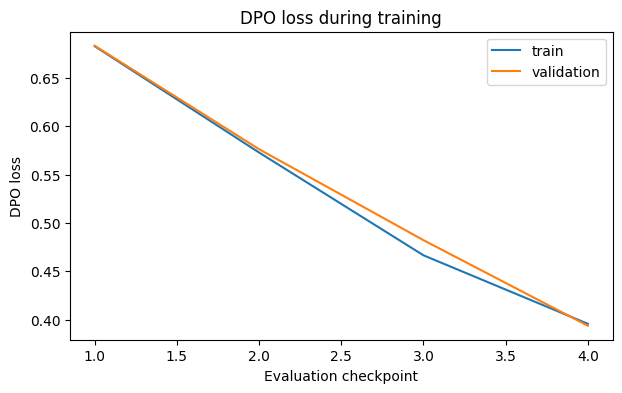

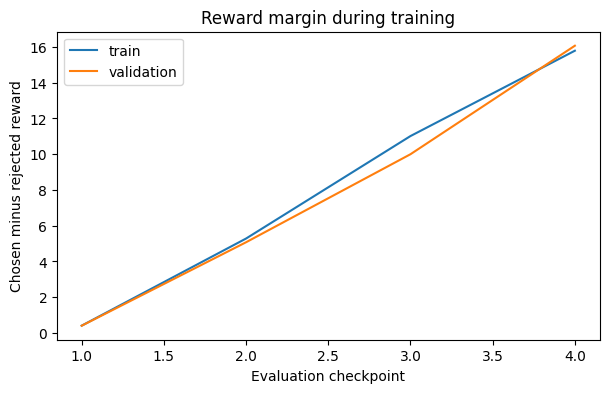

In [21]:

import matplotlib.pyplot as plt

eval_steps = list(range(1, len(tracking["train_losses"]) + 1))

plt.figure(figsize=(7, 4))
plt.plot(eval_steps, tracking["train_losses"], label="train")
plt.plot(eval_steps, tracking["val_losses"], label="validation")
plt.xlabel("Evaluation checkpoint")
plt.ylabel("DPO loss")
plt.title("DPO loss during training")
plt.legend()
plt.show()

train_reward_margins = [c - r for c, r in zip(tracking["train_chosen_rewards"], tracking["train_rejected_rewards"])]
val_reward_margins = [c - r for c, r in zip(tracking["val_chosen_rewards"], tracking["val_rejected_rewards"])]

plt.figure(figsize=(7, 4))
plt.plot(eval_steps, train_reward_margins, label="train")
plt.plot(eval_steps, val_reward_margins, label="validation")
plt.xlabel("Evaluation checkpoint")
plt.ylabel("Chosen minus rejected reward")
plt.title("Reward margin during training")
plt.legend()
plt.show()


## 9. Inspect which held-out geography task families improved most

In [22]:
import pandas as pd

def make_margin_table(entries, policy_model, reference_model, tokenizer, device, max_examples=None):
    summary = summarize_preference_accuracy(
        entries, policy_model, reference_model, tokenizer, device, max_examples=max_examples
    )
    df = pd.DataFrame(summary["rows"])
    return df.sort_values("improvement", ascending=False).reset_index(drop=True)

val_margin_df = make_margin_table(val_run_data, policy_model, reference_model, tokenizer, device, max_examples=len(val_run_data))
val_margin_df[["task_family", "instruction", "reference_margin", "policy_margin", "improvement"]].head(10)


def print_summary_stats(name, df):
    print(name)
    print("-" * len(name))
    print(f"Mean reference margin : {df['reference_margin'].mean():.4f}")
    print(f"Mean policy margin    : {df['policy_margin'].mean():.4f}")
    print(f"Mean improvement      : {df['improvement'].mean():.4f}")
    print(f"Policy win rate       : {(df['policy_margin'] > 0).mean():.2%}")
    print(f"Reference win rate    : {(df['reference_margin'] > 0).mean():.2%}")
    print(f"Improvement rate      : {(df['improvement'] > 0).mean():.2%}")
    if 'task_family' in df.columns:
        print("By-task-family improvement:")
        print(df.groupby('task_family')['improvement'].mean().sort_values(ascending=False))
    print()

print_summary_stats("Validation sample", val_margin_df)

test_margin_df = make_margin_table(test_data, policy_model, reference_model, tokenizer, device, max_examples=len(test_data))
print_summary_stats("Test sample", test_margin_df)

print("Interpretation: higher policy margins mean the tuned model prefers the selected concise style more strongly.")

Validation sample
-----------------
Mean reference margin : 28.1692
Mean policy margin    : 45.8019
Mean improvement      : 17.6327
Policy win rate       : 99.29%
Reference win rate    : 99.29%
Improvement rate      : 100.00%
By-task-family improvement:
task_family
capital_open               22.131531
capital_multiple_choice    20.693750
country_from_capital       19.490324
continent_of_capital       16.557410
continent_of_country       16.198398
capital_yes_no             15.624414
capital_fill_blank         12.732935
Name: improvement, dtype: float64

Test sample
-----------
Mean reference margin : 28.6818
Mean policy margin    : 46.7178
Mean improvement      : 18.0360
Policy win rate       : 98.70%
Reference win rate    : 96.75%
Improvement rate      : 100.00%
By-task-family improvement:
task_family
continent_of_country       22.348070
country_from_capital       19.055936
capital_open               17.831121
capital_multiple_choice    17.698864
capital_yes_no             17.582564
c

**Try your own geography questions**

A good stress test is to ask the model about countries that were held out during training and see whether it now answers with the bare minimum needed.

In [23]:
def build_custom_question_bank_from_test_facts(test_facts):
    bank = []

    if len(test_facts) >= 2:
        bank.append({
            "question": f"What is the capital of {test_facts[0]['country']}?",
            "expected_answer": test_facts[0]["capital"],
        })
        bank.append({
            "question": f"Which country has {test_facts[1]['capital']} as its capital?",
            "expected_answer": test_facts[1]["country"],
        })

    if len(test_facts) >= 4:
        bank.append({
            "question": f"Which continent is {test_facts[2]['country']} in?",
            "expected_answer": test_facts[2]["continent"],
        })
        bank.append({
            "question": f"Which continent is {test_facts[3]['capital']} in?",
            "expected_answer": test_facts[3]["continent"],
        })

    if len(test_facts) >= 6:
        fact = test_facts[4]
        distractor = test_facts[5]["capital"]
        bank.append({
            "question": f"Which of these is the capital of {fact['country']}: {fact['capital']}, {distractor}, or Tokyo?",
            "expected_answer": fact["capital"],
        })
        bank.append({
            "question": f"Answer yes or no: Is {fact['capital']} the capital of {fact['country']}?",
            "expected_answer": "Yes",
        })

    if len(test_facts) >= 8:
        fact = test_facts[6]
        wrong_fact = test_facts[7]
        bank.append({
            "question": f"Answer yes or no: Is {wrong_fact['capital']} the capital of {fact['country']}?",
            "expected_answer": "No",
        })
        bank.append({
            "question": f"Fill in the blank: The capital of {wrong_fact['country']} is ___.",
            "expected_answer": wrong_fact["capital"],
        })

    return bank

custom_question_bank = build_custom_question_bank_from_test_facts(test_country_facts)

print("Custom geography questions loaded:", len(custom_question_bank))
for i, item in enumerate(custom_question_bank, 1):
    print(f"{i}. {item['question']} -> expected: {item['expected_answer']}")

Custom geography questions loaded: 8
1. What is the capital of Germany? -> expected: Berlin
2. Which country has Luxembourg as its capital? -> expected: Luxembourg
3. Which continent is United Kingdom in? -> expected: Europe
4. Which continent is Budapest in? -> expected: Europe
5. Which of these is the capital of Belgium: Brussels, Prague, or Tokyo? -> expected: Brussels
6. Answer yes or no: Is Brussels the capital of Belgium? -> expected: Yes
7. Answer yes or no: Is Belgrade the capital of Vietnam? -> expected: No
8. Fill in the blank: The capital of Serbia is ___. -> expected: Belgrade


In [24]:

def compare_before_after_on_custom_questions(
    question_bank,
    baseline_model,
    dpo_model,
    tokenizer,
    max_new_tokens=8,
    do_sample=False,
):
    print("Before DPO / After DPO on custom questions")
    print("=" * 90)

    before_rows = []
    after_rows = []

    for item in question_bank:
        question = item["question"]
        expected = item["expected_answer"]

        before = generate_response_only(
            baseline_model,
            tokenizer,
            question,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
        )
        after = generate_response_only(
            dpo_model,
            tokenizer,
            question,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
        )

        before_metrics = generation_metrics(before, expected)
        after_metrics = generation_metrics(after, expected)

        before_rows.append(before_metrics)
        after_rows.append(after_metrics)

        print(f"Question       : {question}")
        print(f"Expected       : {expected}")
        print(f"Before DPO     : {before}")
        print(f"After DPO      : {after}")
        print(f"Before metrics : words={before_metrics['response_words']}, starts_with_expected={before_metrics['starts_with_expected']}, exact={before_metrics['exact_match']}")
        print(f"After metrics  : words={after_metrics['response_words']}, starts_with_expected={after_metrics['starts_with_expected']}, exact={after_metrics['exact_match']}")
        print("-" * 90)

    def mean_metric(rows, key):
        return sum(r[key] for r in rows) / len(rows)

    print("Summary")
    print("=" * 90)
    print(f"Avg words before: {mean_metric(before_rows, 'response_words'):.2f}")
    print(f"Avg words after : {mean_metric(after_rows, 'response_words'):.2f}")
    print(f"Starts with expected before: {mean_metric(before_rows, 'starts_with_expected'):.2%}")
    print(f"Starts with expected after : {mean_metric(after_rows, 'starts_with_expected'):.2%}")
    print(f"Exact match before        : {mean_metric(before_rows, 'exact_match'):.2%}")
    print(f"Exact match after         : {mean_metric(after_rows, 'exact_match'):.2%}")

compare_before_after_on_custom_questions(
    custom_question_bank,
    reference_model,
    policy_model,
    tokenizer,
    max_new_tokens=8,
    do_sample=False,
)


Before DPO / After DPO on custom questions
Question       : What is the capital of Germany?
Expected       : Berlin
Before DPO     : Berlin
After DPO      : Berlin
Before metrics : words=1, starts_with_expected=True, exact=True
After metrics  : words=1, starts_with_expected=True, exact=True
------------------------------------------------------------------------------------------


C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:650: UserWarning: `do

Question       : Which country has Luxembourg as its capital?
Expected       : Luxembourg
Before DPO     : Luxembourg is a country, not a
After DPO      : France
Before metrics : words=6, starts_with_expected=True, exact=False
After metrics  : words=1, starts_with_expected=False, exact=False
------------------------------------------------------------------------------------------
Question       : Which continent is United Kingdom in?
Expected       : Europe
Before DPO     : Europe
After DPO      : Europe
Before metrics : words=1, starts_with_expected=True, exact=True
After metrics  : words=1, starts_with_expected=True, exact=True
------------------------------------------------------------------------------------------
Question       : Which continent is Budapest in?
Expected       : Europe
Before DPO     : Budapest is located in Europe,
After DPO      : Europe
Before metrics : words=5, starts_with_expected=False, exact=False
After metrics  : words=1, starts_with_expected=True, exact=

**Your tasks**


If you're starting this before the DPO lecture, you should focus on the dataset creation part. Can you improve it? Can you expand it? Get creative! Even better... can you think of an alternative task that you can rebuild the notebook around?

If you're only starting this after the DPO lecture, first of all, make sure you understand what we are doing here, so you can take the Moodle quiz. After you've worked your way through the notebook, you can also address specific points.
* Try different models and see what changes
* Perform an ablation study (remove components and see what happens)
* Fix the low-hanging fruit (e.g., implement normalization so Bogotá and Bogota map to the same token).

To get your grade, please complete the Moodle Quiz on alignment (available after Easter).




In [25]:
# ==========================================
# EXPERIMENT: ABLATION STUDY (BETA PARAMETER, at 0 removes the reference model's influence entirely)
# ==========================================
import time

print("Starting Ablation Study: Training WITHOUT KL Divergence Penalty (beta = 0.0)")

# 1. Re-initialize a fresh policy model from the base checkpoint
ablated_policy_model = copy.deepcopy(model)
ablated_policy_model.to(device)

# 2. Setup a new optimizer
ablated_optimizer = torch.optim.AdamW(ablated_policy_model.parameters(), lr=1e-6, weight_decay=0.01)

start_time = time.time()
torch.manual_seed(123)

# 3. Train with beta = 0.0 (Removes the reference model component constraint)
ablated_tracking = train_model_dpo_simple(
    policy_model=ablated_policy_model,
    reference_model=reference_model, # Still passed, but effect is zeroed out by beta=0.0
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=ablated_optimizer,
    num_epochs=1,
    beta=0.0, # ABLATION: Set to 0.0 to disable the KL penalty
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    start_context=format_input(benchmark_entries[0]),
    tokenizer=tokenizer
)

print(f"Ablated training completed in {(time.time() - start_time) / 60:.2f} minutes.")

# 4. Evaluate the ablated model against the test set
print("\nEvaluating Ablated Model on Custom Questions...")
compare_before_after_on_custom_questions(
    custom_question_bank,
    reference_model,
    ablated_policy_model,
    tokenizer,
    max_new_tokens=8,
    do_sample=False,
)

Starting Ablation Study: Training WITHOUT KL Divergence Penalty (beta = 0.0)
Ep 1 (Step 000000): Train loss 0.691, Val loss 0.691, Train reward margins 0.000, Val reward margins 0.000
Ep 1 (Step 000028): Train loss 0.691, Val loss 0.691, Train reward margins 0.000, Val reward margins 0.000
Ep 1 (Step 000056): Train loss 0.691, Val loss 0.691, Train reward margins 0.000, Val reward margins 0.000
Ep 1 (Step 000084): Train loss 0.691, Val loss 0.691, Train reward margins 0.000, Val reward margins 0.000
Epoch 1 greedy sample response: Singapore -> capital: Singapore City
Ablated training completed in 9.67 minutes.

Evaluating Ablated Model on Custom Questions...
Before DPO / After DPO on custom questions
Question       : What is the capital of Germany?
Expected       : Berlin
Before DPO     : Berlin
After DPO      : Berlin
Before metrics : words=1, starts_with_expected=True, exact=True
After metrics  : words=1, starts_with_expected=True, exact=True
-----------------------------------------

In [26]:
# ==========================================
# EXPERIMENT: ABLATION STUDY (BETA PARAMETER, at 0 removes the reference model's influence entirely)
# ==========================================
import time

print("Starting Ablation Study: Training WITHOUT KL Divergence Penalty (beta = 0.5)")

# 1. Re-initialize a fresh policy model from the base checkpoint
ablated_policy_model = copy.deepcopy(model)
ablated_policy_model.to(device)

# 2. Setup a new optimizer
ablated_optimizer = torch.optim.AdamW(ablated_policy_model.parameters(), lr=1e-6, weight_decay=0.01)

start_time = time.time()
torch.manual_seed(123)

# 3. Train with beta = 0.0 (Removes the reference model component constraint)
ablated_tracking = train_model_dpo_simple(
    policy_model=ablated_policy_model,
    reference_model=reference_model, # Still passed, but effect is zeroed out by beta=0.0
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=ablated_optimizer,
    num_epochs=1,
    beta=0.5, # ABLATION: Set to 0.0 to disable the KL penalty
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    start_context=format_input(benchmark_entries[0]),
    tokenizer=tokenizer
)

print(f"Ablated training completed in {(time.time() - start_time) / 60:.2f} minutes.")

# 4. Evaluate the ablated model against the test set
print("\nEvaluating Ablated Model on Custom Questions...")
compare_before_after_on_custom_questions(
    custom_question_bank,
    reference_model,
    ablated_policy_model,
    tokenizer,
    max_new_tokens=8,
    do_sample=False,
)

Starting Ablation Study: Training WITHOUT KL Divergence Penalty (beta = 0.5)
Ep 1 (Step 000000): Train loss 0.620, Val loss 0.617, Train reward margins 0.326, Val reward margins 0.336
Ep 1 (Step 000028): Train loss 0.111, Val loss 0.116, Train reward margins 4.929, Val reward margins 4.914
Ep 1 (Step 000056): Train loss 0.029, Val loss 0.032, Train reward margins 9.190, Val reward margins 8.644
Ep 1 (Step 000084): Train loss 0.009, Val loss 0.011, Train reward margins 12.034, Val reward margins 12.027


C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
C:\Users\pd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\generation\configuration_utils.py:650: UserWarning: `do

Epoch 1 greedy sample response: Singapore -> capital: Singapore City
Ablated training completed in 12.30 minutes.

Evaluating Ablated Model on Custom Questions...
Before DPO / After DPO on custom questions
Question       : What is the capital of Germany?
Expected       : Berlin
Before DPO     : Berlin
After DPO      : Berlin
Before metrics : words=1, starts_with_expected=True, exact=True
After metrics  : words=1, starts_with_expected=True, exact=True
------------------------------------------------------------------------------------------
Question       : Which country has Luxembourg as its capital?
Expected       : Luxembourg
Before DPO     : Luxembourg is a country, not a
After DPO      : Luxembourg
Before metrics : words=6, starts_with_expected=True, exact=False
After metrics  : words=1, starts_with_expected=True, exact=True
------------------------------------------------------------------------------------------
Question       : Which continent is United Kingdom in?
Expected     